In [ ]:
# 1. IMPORTAÇÕES
# 2. COLETA  DOS DADOS DA SÉRIE TEMPORAL
# 3. VISUALIZAÇÃO DA SÉRIE TEMPORAL
# 4. NORMALIZAÇÃO DOS DADOS
# 5. CRIAÇÃO DAS JANELAS TEMPORAIS
# 6. SEPARAÇÃO TREINO / TESTE (SEM EMBARALHAR)
# 7. CONSTRUÇÃO DO MODELO LSTM
# 8. TREINAMENTO DO MODELO
# 9. AVALIAÇÃO DO MODELO
# 10. VISUALIZAÇÃO DAS PREVISÕES
# 11. PREVISÃO DO PRÓXIMO DIA

In [ ]:
# Importações
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from os import stat
# Coleta dos dados
ticker = "TSLA"
start_date = "2015-01-01" # aaaa-mm-dd
end_date = None # Data final == hoje

df = yf.download(ticker, start=start_date, end=end_date)
print()
print(df.head())
print(df.tail())

# Usar apenas o valor de fechamento 'Close'
series = df[['Close']].dropna()
print(series)

/tmp/ipython-input-928436216.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price           Close       High        Low       Open    Volume
Ticker           TSLA       TSLA       TSLA       TSLA      TSLA
Date                                                            
2015-01-02  14.620667  14.883333  14.217333  14.858000  71466000
2015-01-05  14.006000  14.433333  13.810667  14.303333  80527500
2015-01-06  14.085333  14.280000  13.614000  14.004000  93928500
2015-01-07  14.063333  14.318667  13.985333  14.223333  44526000
2015-01-08  14.041333  14.253333  14.000667  14.187333  51637500
Price            Close        High         Low        Open    Volume
Ticker            TSLA        TSLA        TSLA        TSLA      TSLA
Date                                                                
2026-02-05  397.209991  402.100006  387.529999  397.019989  72819800
2026-02-06  411.109985  414.549988  397.750000  400.869995  62677100
2026-02-09  417.320007  421.250000  407.290009  409.910004  54484300
2026-02-10  425.209991  427.250000  417.000000  418.079987  64450

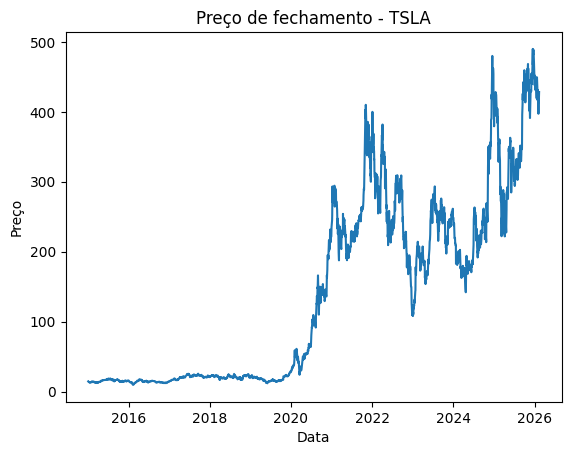

In [ ]:
# Visualização da série temporal
plt.figure()
plt.plot(series)
plt.title(f"Preço de fechamento - {ticker}")
plt.xlabel("Data")
plt.ylabel("Preço")
plt.show()

In [ ]:
# 4. NORMALIZAÇÃO DOS DADOS
scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series.values)
print(series_scaled)

[[0.01049895]
 [0.0092192 ]
 [0.00938437]
 ...
 [0.84892839]
 [0.86535552]
 [0.87172651]]


In [ ]:
# 5. CRIAÇÃO DAS JANELAS TEMPORAIS
def create_windows(data, window_size):
  X, y = [], []
  for i in range(len(data) - window_size):
    X.append(data[i:i + window_size])
    y.append(data[i + window_size])
  return np.array(X), np.array(y)

window_size = 30 # 30 dias, pode mudar para verificar possíveis melhorias

X, y = create_windows(series_scaled, window_size)

print(f"Formato do X: {X.shape}")
print(f"Formato do y: {y.shape}")



Formato do X: (2764, 30, 1)
Formato do y: (2764, 1)


In [ ]:
# 6. SEPARAÇÃO TREINO / TESTE (SEM EMBARALHAR)
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Treino: {X_train.shape}")
print(f"Teste: {X_test.shape}")


Treino: (2211, 30, 1)
Teste: (553, 30, 1)


In [ ]:
# 7. CONSTRUÇÃO DO MODELO LSTM
model = Sequential()
model.add(LSTM(50, activation='tanh', input_shape=(window_size, 1)))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 8. TREINAMENTO DO MODELO
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0091 - val_loss: 0.0017
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.6176e-04 - val_loss: 0.0016
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.6558e-04 - val_loss: 0.0014
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.4075e-04 - val_loss: 0.0017
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.5770e-04 - val_loss: 0.0014
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.2810e-04 - val_loss: 0.0013
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.9616e-04 - val_loss: 0.0011
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 2.2918e-04 - val_loss: 9.9059e-04
Epoch 9/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 2.5220e-04 - val_loss: 0.0010
Epoch 10/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 2.4029e-04 - val_loss: 9.0405e-04
Epoch 11/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 2.2120e-04 - val_loss: 8.7561e-04
Epoch 12/50

In [ ]:
# 9. Avaliação do modelo
y_pred = model.predict(X_test)

y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
print(f"RMSE: {rmse}")

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
RMSE: 13.719819665881811


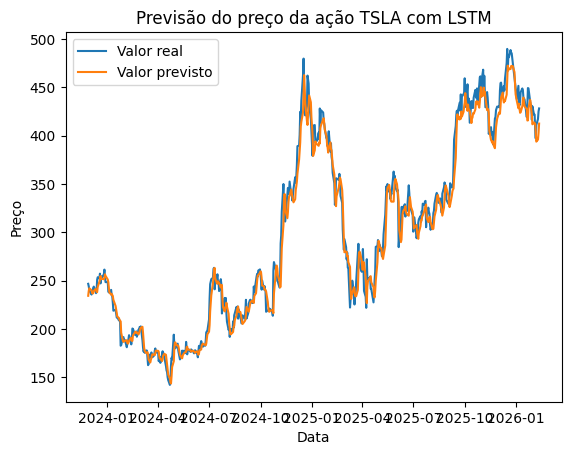

In [ ]:
# 10. Visualização das previsões
plt.figure()
plt.plot(series.index[-len(y_test):], y_test_inv, label="Valor real")
plt.plot(series.index[-len(y_test):], y_pred_inv, label="Valor previsto")
plt.title(f"Previsão do preço da ação {ticker} com LSTM")
plt.xlabel("Data")
plt.ylabel("Preço")
plt.legend()
plt.show()

In [ ]:
# 11. Previsão de fechamento do próximo dia
last_window = series_scaled[-window_size:]
last_window = last_window.reshape(1, window_size, 1)

next_day_pred = model.predict(last_window) # valor entre 0 e 1
next_day_price = scaler.inverse_transform(next_day_pred) # valor previsto em dólares

print(f"Previsão de preço da {ticker} para o próximo dia: ${next_day_price[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Previsão de preço da TSLA para o próximo dia: $419.81
